### Iterative Workflows in LangGraph
Iterative (or looping) workflows are a type of LangGraph architecture where tasks loop back and forth to iteratively improve an outcome
. Unlike sequential or parallel workflows, iterative workflows are crucial for complex tasks where the first attempt by an LLM might be mediocre and requires refinement

The Real-World Use Case: To solve the problem of generating high-quality automated social media posts (specifically X/Twitter), a single LLM prompt often yields unsatisfactory results
. To fix this, an iterative workflow is built using three LLM agents:
1. Generator: Generates an initial tweet on a given topic
.
2. Evaluator: A strict critic that evaluates the tweet against specific guidelines (humor, originality, format). It outputs a structured response: an evaluation status ("Approved" or "Needs Improvement") and constructive feedback
.
3. Optimizer: Takes the rejected tweet and the evaluator's feedback to rewrite and improve the post
.
The workflow loops between the Evaluator and Optimizer until the tweet is either approved or hits a maximum iteration limit to prevent infinite loops

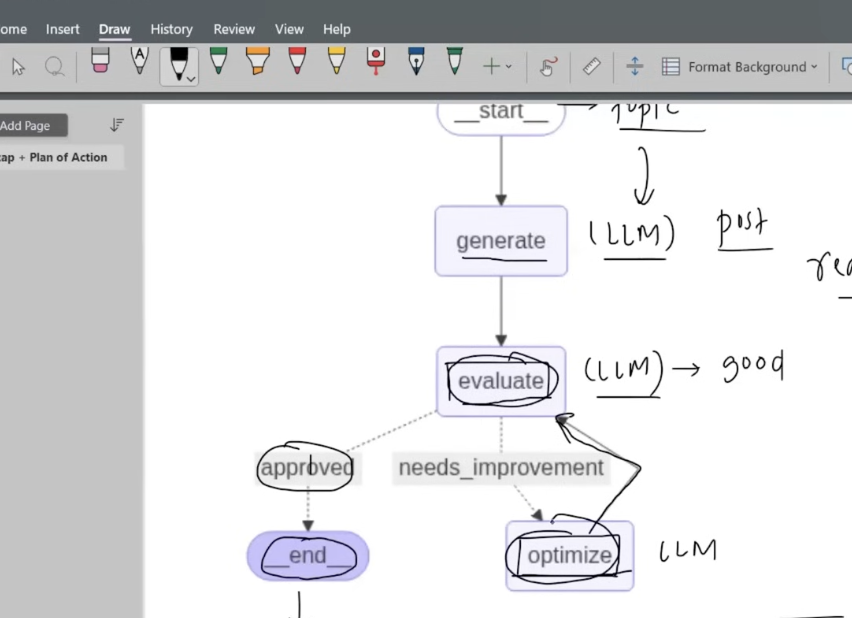

Important rule in LangGraph

👉 Nodes should return:

only the fields they want to update

In [43]:
from langgraph.graph import StateGraph , START , END 
# state is shared memory between all nodes 
# it should use a standard 
# so TypedDict 
from typing import TypedDict , Literal , Annotated
# reducers -> it tells langgraph how to combine old data with new data.
# Annoted is used to add metadata to a Type 
# here we use it to add reducers to a type 
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage , HumanMessage
import os 


In [44]:
load_dotenv()

True

In [45]:
generator_llm = ChatGoogleGenerativeAI(api_key=os.getenv('GEMINI_API_KEY') , model = 'gemini-3-flash-preview')
evaluator_llm = ChatGoogleGenerativeAI(api_key=os.getenv('GEMINI_API_KEY') , model = 'gemini-3-flash-preview')
optimizer_llm = ChatGoogleGenerativeAI(api_key=os.getenv('GEMINI_API_KEY') , model = 'gemini-3-flash-preview')
 

In [46]:
from pydantic import BaseModel , Field 
class Evaluation_output_schema(BaseModel) :
    evaluation : Literal['approved' , 'needs_improvement'] = Field(...) # this means that this field is mendatory
    feedback : str = Field(...) 


In [47]:
optimizer_llm_with_structered_output = optimizer_llm.with_structured_output(Evaluation_output_schema)
# now this llm will output just like the schema . 


In [48]:
# defining the state 
class TweetState(TypedDict) :
    topic : str 
    tweet : str 
    iteration : int
    evaluation : Literal['approved' , 'need_impovement']
    feedback : str 


In [65]:
def generate_tweet(state : TweetState) -> TweetState : 
    # prompt 
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    res  =generator_llm.invoke(messages).content[0]['text']
    print(res)
    return {"tweet" : res}


def evaluate_tweet(state : TweetState) -> TweetState :
    # prompt 
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    res = optimizer_llm_with_structered_output.invoke(messages)
    print('res2' , res )
    return {'evaluation' : res.evaluation , 'feedback' : res.feedback }

def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content[0]['text']
    print('res3' , response)
    
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration,}



In [66]:
def check(state : TweetState) :
    if (state['evaluation'] == 'approved') or state['iteration'] > 5:
        return 'approved' 
    else :
        return 'not_approved'
    

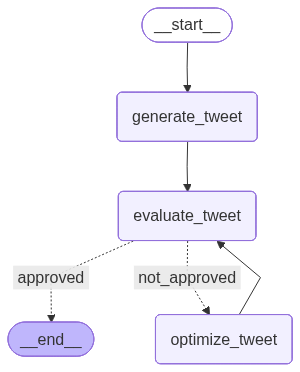

In [67]:
graph = StateGraph(TweetState)

graph.add_node('generate_tweet' , generate_tweet)
graph.add_node('evaluate_tweet' , evaluate_tweet)
graph.add_node('optimize_tweet' , optimize_tweet)

graph.add_edge(START , 'generate_tweet')
graph.add_edge('generate_tweet' , 'evaluate_tweet')

graph.add_conditional_edges('evaluate_tweet' , check , {'approved' : END  , 'not_approved' : 'optimize_tweet'} )

graph.add_edge('optimize_tweet' , 'evaluate_tweet')
workflow = graph.compile()
workflow

In [68]:
initial_state = {
    "topic": "peacocks",
    "iteration": 1,
    
}
result = workflow.invoke(initial_state)
result

Peacocks are just pigeons that went to art school and never let you forget it. Imagine having a 6-foot cape made of literal eyeballs and still deciding your best quality is screaming like a Victorian ghost at 4 AM. Absolute top-tier main character energy.
res2 evaluation='needs_improvement' feedback="The comparison of peacocks to art school pigeons is a solid premise, but the execution is buried under wordy, derivative descriptors that feel dated. Phrases like 'Victorian ghost' and 'literal eyeballs' are trying too hard to be quirky, and the ending 'top-tier main character energy' is a quintessential example of a generic, throwaway line that weakens the humor by explaining the joke. To work as a high-impact tweet, it needs to cut the fluff and avoid leaning on overused internet slang that acts as a substitute for a genuine punchline."
res3 Peacocks are just pigeons with an MFA. Imagine evolving a six-foot sequined cape just to spend your life screaming like a car alarm in a tuxedo.
res

{'topic': 'peacocks',
 'tweet': 'Peacocks are just pigeons with an MFA. Imagine evolving a six-foot sequined cape just to spend your life screaming like a car alarm in a tuxedo.',
 'iteration': 2,
 'evaluation': 'approved',
 'feedback': "The tweet successfully leverages the popular 'Animal X is just Animal Y with a degree' trope, but elevates it with sharp, specific imagery like 'sequined cape' and 'car alarm in a tuxedo.' It fits the Twitter format perfectly, avoiding the dated setup-punchline structure in favor of a cohesive observational thought. While the comparison is not entirely groundbreaking, the punchiness and distinct visual metaphors provide strong virality potential and a crisp, cynical edge that resonates with contemporary internet humor."}